# Griffiths QM
## Chapter 9: Time-Dependent Perturbation Theory — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 9.1](#prob_9_1)   | Two-Level System — Rabi Oscillations |
| [Problem 9.3](#prob_9_3)   | Sinusoidal Perturbation — Resonance & Fermi's Golden Rule |
| [Problem 9.4](#prob_9_4)   | Rabi Formula — Resonance vs Off-Resonance |
| [Problem 9.9](#prob_9_9)   | Hydrogen 2p Lifetime — Lyman-alpha |
| [Problem 9.13](#prob_9_13) | Rabi Oscillations — NMR Analogy |
| [Problem 9.14](#prob_9_14) | Berry's Phase — Solid Angle |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 9.1 — Two-Level System: Rabi Oscillations {#prob_9_1}

Exact solution: $|c_b(t)|^2 = \dfrac{|H'_{ab}|^2/\hbar^2}{\Omega^2}\sin^2(\Omega t)$,
$\quad\Omega = \sqrt{\omega_0^2 + |H'_{ab}|^2/\hbar^2}$


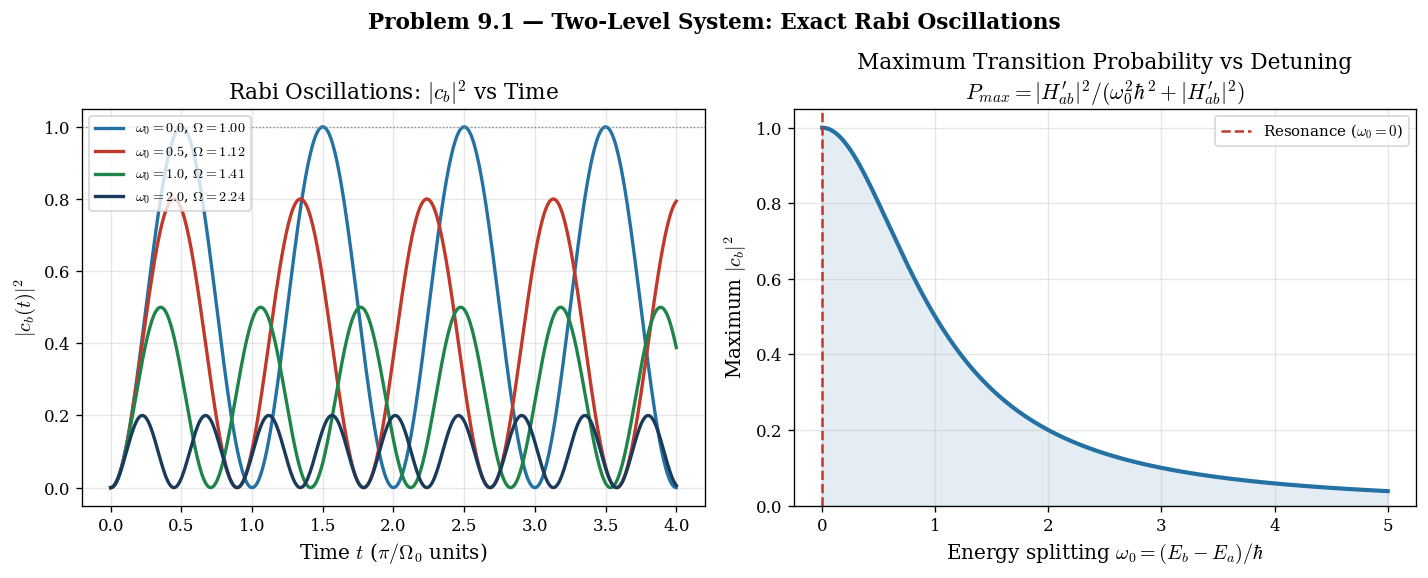

At resonance (omega_0=0): P_max = 1.0 (complete flip) ✓
Off-resonance: P_max < 1, oscillation faster ✓


In [2]:
# Figure 9.1: Rabi oscillations in a two-level system
hbar = 1.0
Hab  = 1.0   # coupling |H'_ab| / hbar
t    = np.linspace(0, 4*np.pi, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: P_b(t) for several detunings omega_0
ax = axes[0]
omega0_vals = [0.0, 0.5, 1.0, 2.0]
col_om = [BLUE, RED, GREEN, NAVY]
for w0, c in zip(omega0_vals, col_om):
    Omega = np.sqrt(w0**2 + Hab**2)
    Pb = (Hab/Omega)**2 * np.sin(Omega*t)**2
    ax.plot(t/np.pi, Pb, color=c, lw=2,
            label=fr'$\omega_0={w0}$, $\Omega={Omega:.2f}$')
ax.set_xlabel(r'Time $t$ ($\pi/\Omega_0$ units)')
ax.set_ylabel(r'$|c_b(t)|^2$')
ax.set_title('Rabi Oscillations: $|c_b|^2$ vs Time')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
ax.axhline(1.0, color=GRAY, lw=0.8, ls=':')

# Right: max P_b vs detuning
ax2 = axes[1]
w0_arr = np.linspace(0, 5, 300)
Pb_max = Hab**2 / (w0_arr**2 + Hab**2)
ax2.plot(w0_arr, Pb_max, color=BLUE, lw=2.5)
ax2.fill_between(w0_arr, 0, Pb_max, alpha=0.12, color=BLUE)
ax2.axvline(0, color=RED, lw=1.5, ls='--', label='Resonance ($\\omega_0=0$)')
ax2.set_xlabel(r'Energy splitting $\omega_0 = (E_b-E_a)/\hbar$')
ax2.set_ylabel(r'Maximum $|c_b|^2$')
ax2.set_title('Maximum Transition Probability vs Detuning\n'
              r'$P_{max} = |H_{ab}^\prime|^2/(\omega_0^2\hbar^2 + |H_{ab}^\prime|^2)$')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 9.1 — Two-Level System: Exact Rabi Oscillations',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_9_1.png')); plt.show()
print('At resonance (omega_0=0): P_max = 1.0 (complete flip) ✓')
print('Off-resonance: P_max < 1, oscillation faster ✓')


---
## Problem 9.3 — Sinusoidal Perturbation: Resonance {#prob_9_3}

$$P_{i\to f}(t) \approx \frac{|V_{fi}|^2}{\hbar^2}
\frac{\sin^2[(\omega_{fi}-\omega)t/2]}{(\omega_{fi}-\omega)^2/4}$$


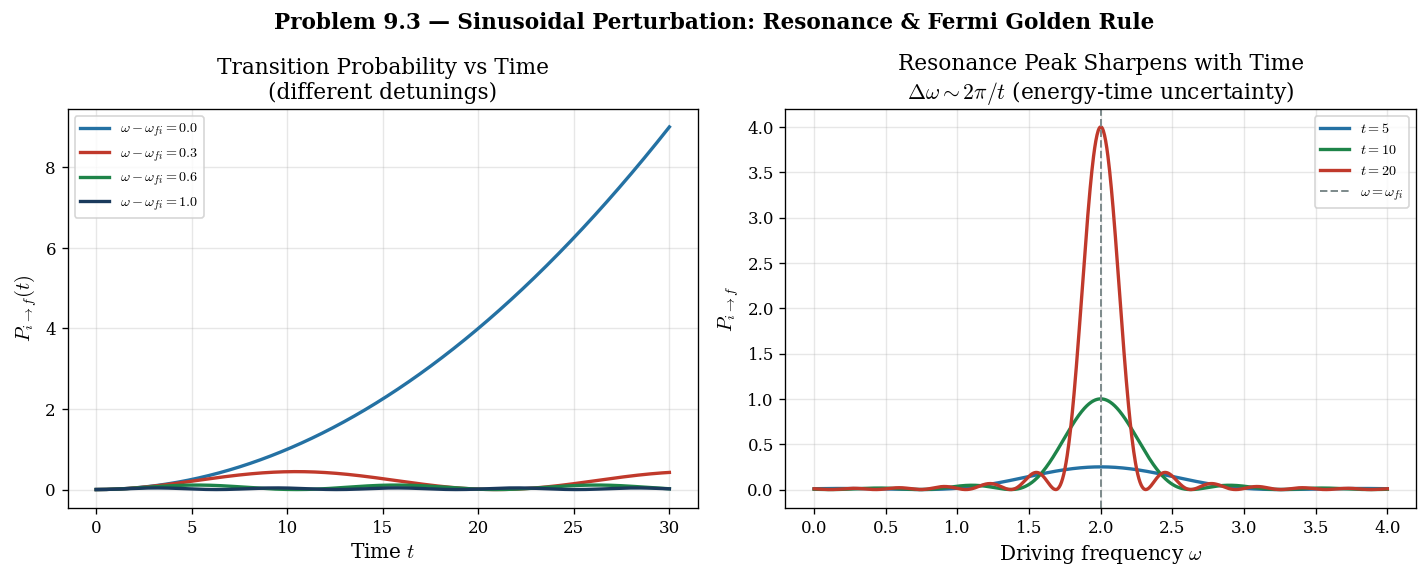

In [3]:
# Figure 9.3: Sinusoidal perturbation — transition probability vs time and frequency
hbar   = 1.0
Vfi    = 0.1   # |V_fi| / hbar
wfi    = 2.0   # transition frequency

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: P(t) for several detunings (omega - omega_fi)
ax = axes[0]
t_arr = np.linspace(0, 30, 1000)
detunings = [0.0, 0.3, 0.6, 1.0]
col_d = [BLUE, RED, GREEN, NAVY]
for det, c in zip(detunings, col_d):
    omega = wfi + det
    x = (wfi - omega) * t_arr / 2
    P = (Vfi/hbar)**2 * np.sinc(x/np.pi)**2 * t_arr**2
    ax.plot(t_arr, P, color=c, lw=2,
            label=fr'$\omega-\omega_{{fi}}={det}$')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'$P_{i\to f}(t)$')
ax.set_title('Transition Probability vs Time\n(different detunings)')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

# Right: P vs omega at fixed t — resonance peak
ax2 = axes[1]
omega_arr = np.linspace(wfi - 2.0, wfi + 2.0, 1000)
t_fixed_vals = [5, 10, 20]
col_t = [BLUE, GREEN, RED]
for t_fix, c in zip(t_fixed_vals, col_t):
    x = (wfi - omega_arr) * t_fix / 2
    with np.errstate(divide='ignore', invalid='ignore'):
        sinc2 = np.where(np.abs(x) < 1e-10, 1.0, (np.sin(x)/x)**2)
    P = (Vfi/hbar)**2 * sinc2 * t_fix**2
    ax2.plot(omega_arr, P, color=c, lw=2, label=fr'$t={t_fix}$')
ax2.axvline(wfi, color=GRAY, ls='--', lw=1.2, label=r'$\omega=\omega_{fi}$')
ax2.set_xlabel(r'Driving frequency $\omega$')
ax2.set_ylabel(r'$P_{i\to f}$')
ax2.set_title('Resonance Peak Sharpens with Time\n'
              r'$\Delta\omega \sim 2\pi/t$ (energy-time uncertainty)')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 9.3 — Sinusoidal Perturbation: Resonance & Fermi Golden Rule',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_9_3.png')); plt.show()


---
## Problem 9.4 — Rabi Formula: Resonance vs Off-Resonance {#prob_9_4}

$$P_{a\to b}(t) = \frac{\Omega_0^2}{\Omega_R^2}\sin^2\!\left(\frac{\Omega_R t}{2}\right),
\quad \Omega_R = \sqrt{\Omega_0^2+\delta^2}$$


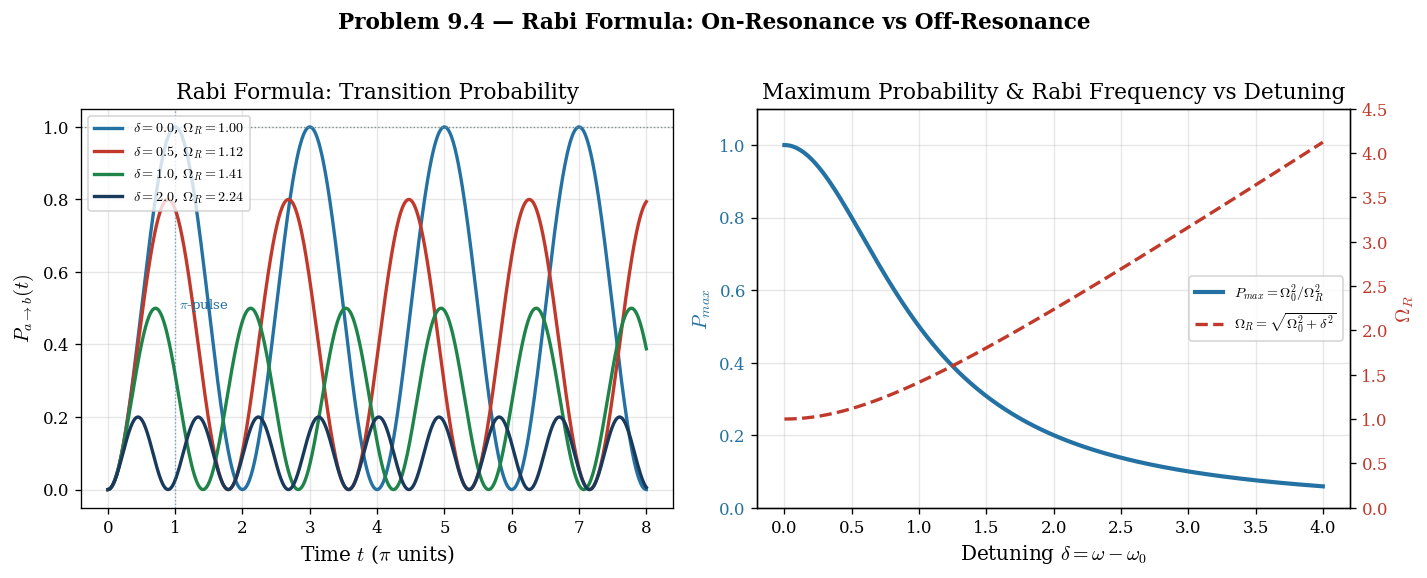

At resonance: P_max = 1.0, Omega_R = Omega_0 = 1.00 ✓
Off-resonance (delta=2): P_max = 0.2000 < 1 ✓


In [4]:
# Figure 9.4: Rabi formula — resonance vs off-resonance
Omega0 = 1.0   # coupling (pi-pulse Rabi frequency)
t = np.linspace(0, 8*np.pi, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: P_ab(t) for several detunings
ax = axes[0]
deltas = [0.0, 0.5, 1.0, 2.0]
col_d  = [BLUE, RED, GREEN, NAVY]
for delta, c in zip(deltas, col_d):
    OmegaR = np.sqrt(Omega0**2 + delta**2)
    Pab = (Omega0/OmegaR)**2 * np.sin(OmegaR*t/2)**2
    ax.plot(t/np.pi, Pab, color=c, lw=2,
            label=fr'$\delta={delta}$, $\Omega_R={OmegaR:.2f}$')
ax.axhline(1.0, color=GRAY, lw=0.8, ls=':')
ax.set_xlabel(r'Time $t$ ($\pi$ units)')
ax.set_ylabel(r'$P_{a\to b}(t)$')
ax.set_title('Rabi Formula: Transition Probability')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
# Annotate pi-pulse
ax.axvline(1.0, color=BLUE, lw=0.8, ls=':', alpha=0.6)
ax.text(1.05, 0.5, r'$\pi$-pulse', fontsize=8, color=BLUE)

# Right: P_max and Omega_R vs detuning
ax2 = axes[1]
delta_arr = np.linspace(0, 4, 300)
OmR_arr   = np.sqrt(Omega0**2 + delta_arr**2)
Pmax_arr  = (Omega0/OmR_arr)**2
ax2.plot(delta_arr, Pmax_arr, color=BLUE, lw=2.5, label=r'$P_{max} = \Omega_0^2/\Omega_R^2$')
ax2_r = ax2.twinx()
ax2_r.plot(delta_arr, OmR_arr, color=RED, lw=2, ls='--', label=r'$\Omega_R = \sqrt{\Omega_0^2+\delta^2}$')
ax2.set_xlabel(r'Detuning $\delta = \omega - \omega_0$')
ax2.set_ylabel(r'$P_{max}$', color=BLUE)
ax2_r.set_ylabel(r'$\Omega_R$', color=RED)
ax2.tick_params(axis='y', labelcolor=BLUE)
ax2_r.tick_params(axis='y', labelcolor=RED)
ax2.set_title('Maximum Probability & Rabi Frequency vs Detuning')
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, labs1+labs2, fontsize=8.5, loc='center right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.1); ax2_r.set_ylim(0, 4.5)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 9.4 — Rabi Formula: On-Resonance vs Off-Resonance',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_9_4.png')); plt.show()
print(f'At resonance: P_max = 1.0, Omega_R = Omega_0 = {Omega0:.2f} ✓')
print(f'Off-resonance (delta=2): P_max = {(Omega0/np.sqrt(Omega0**2+4))**2:.4f} < 1 ✓')


---
## Problem 9.9 — Hydrogen 2p Lifetime (Lyman-alpha) {#prob_9_9}

$\tau_{2p} = 1/A \approx 1.6$ ns for $2p\to 1s$ transition


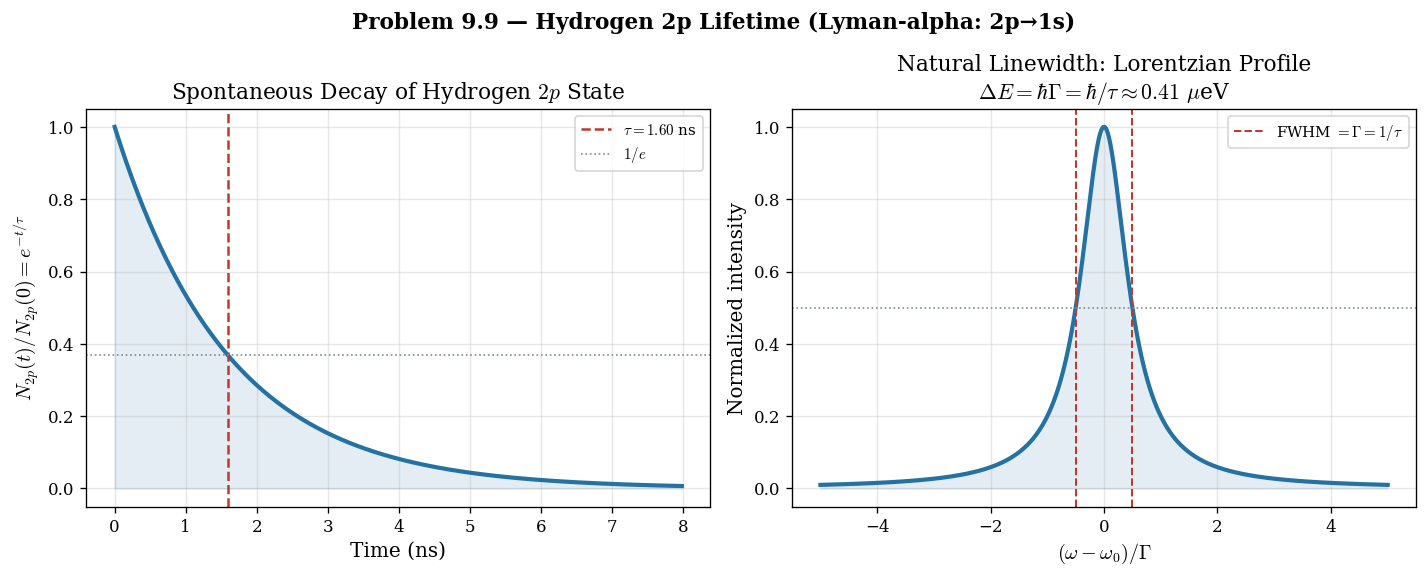

Transition frequency: omega = 1.5497e+16 rad/s
A coefficient: A = 6.2604e+08 s^-1
Lifetime: tau = 1.5973 ns
Natural linewidth: Delta_E = hbar*A = 0.4121 micro-eV


In [5]:
# Figure 9.9: Hydrogen 2p spontaneous emission rate and natural linewidth
import scipy.constants as const

# Physical constants
hbar   = const.hbar
e      = const.e
m_e    = const.m_e
eps0   = const.epsilon_0
c      = const.c
a0     = const.physical_constants['Bohr radius'][0]

# Transition frequency (2p -> 1s): E_2 - E_1 = (3/4) * 13.6 eV
E_Lya  = 3/4 * 13.6 * e   # Joules
omega  = E_Lya / hbar

# Dipole matrix element squared: sum over m of |<1s|r|2p,m>|^2 = 2^15 / 3^10 * a0^2
d2 = (2**15 / 3**10) * a0**2

# Einstein A coefficient
A = e**2 * omega**3 * d2 / (3 * np.pi * eps0 * hbar * c**3)
tau = 1.0 / A

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: population decay N_2p(t) = e^{-t/tau}
ax = axes[0]
t_arr = np.linspace(0, 5*tau*1e9, 500)   # in ns
N_2p  = np.exp(-t_arr / (tau*1e9))
ax.plot(t_arr, N_2p, color=BLUE, lw=2.5)
ax.fill_between(t_arr, 0, N_2p, alpha=0.12, color=BLUE)
ax.axvline(tau*1e9, color=RED, ls='--', lw=1.5,
           label=fr'$\tau = {tau*1e9:.2f}$ ns')
ax.axhline(1/np.e, color=GRAY, ls=':', lw=1, label='$1/e$')
ax.set_xlabel('Time (ns)')
ax.set_ylabel(r'$N_{2p}(t)/N_{2p}(0) = e^{-t/\tau}$')
ax.set_title(r'Spontaneous Decay of Hydrogen $2p$ State')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Right: natural linewidth and energy-time uncertainty
ax2 = axes[1]
# Lorentzian lineshape: L(omega) ~ (Gamma/2pi) / [(omega-omega0)^2 + (Gamma/2)^2]
Gamma    = A   # natural linewidth (rad/s) = 1/tau
omega0   = omega
dw_range = 5 * Gamma
om_arr   = np.linspace(omega0 - dw_range, omega0 + dw_range, 1000)
Lorenz   = (Gamma/(2*np.pi)) / ((om_arr - omega0)**2 + (Gamma/2)**2)
Lorenz  /= Lorenz.max()

ax2.plot((om_arr - omega0)/Gamma, Lorenz, color=BLUE, lw=2.5)
ax2.fill_between((om_arr - omega0)/Gamma, 0, Lorenz, alpha=0.12, color=BLUE)
ax2.axvline(-0.5, color=RED, ls='--', lw=1.2)
ax2.axvline( 0.5, color=RED, ls='--', lw=1.2, label=r'FWHM $= \Gamma = 1/\tau$')
ax2.axhline(0.5, color=GRAY, ls=':', lw=1)
ax2.set_xlabel(r'$(\omega - \omega_0) / \Gamma$')
ax2.set_ylabel('Normalized intensity')
ax2.set_title('Natural Linewidth: Lorentzian Profile\n'
              fr'$\Delta E = \hbar\Gamma = \hbar/\tau \approx {hbar/tau*1e6/e:.2f}$ $\mu$eV')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 9.9 — Hydrogen 2p Lifetime (Lyman-alpha: 2p→1s)',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_9_9.png')); plt.show()
print(f'Transition frequency: omega = {omega:.4e} rad/s')
print(f'A coefficient: A = {A:.4e} s^-1')
print(f'Lifetime: tau = {tau*1e9:.4f} ns')
print(f'Natural linewidth: Delta_E = hbar*A = {hbar*A/e*1e6:.4f} micro-eV')


---
## Problem 9.13 — Rabi Oscillations: NMR Analogy {#prob_9_13}

$$P_{\uparrow\to\downarrow}(t) = \frac{\Omega_0^2}{\Omega_R^2}\sin^2\!\left(\frac{\Omega_R t}{2}\right),
\quad \Omega_R = \sqrt{\Omega_0^2+\delta^2}$$


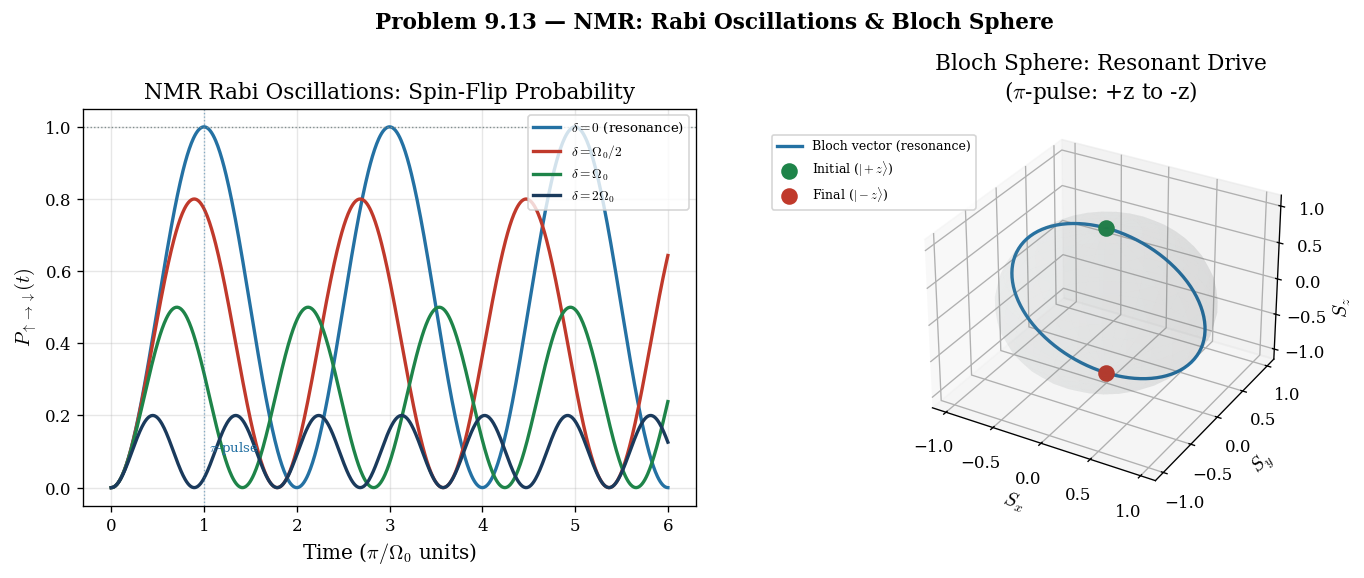

In [6]:
# Figure 9.13: NMR Rabi oscillations
Omega0 = 1.0   # Rabi frequency (gamma*B1)
t = np.linspace(0, 6*np.pi, 800)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: spin-flip probability for various detunings
ax = axes[0]
delta_vals = [0.0, Omega0*0.5, Omega0, Omega0*2]
col_d = [BLUE, RED, GREEN, NAVY]
labels = [r'$\delta=0$ (resonance)', r'$\delta=\Omega_0/2$',
          r'$\delta=\Omega_0$', r'$\delta=2\Omega_0$']
for delta, c, lbl in zip(delta_vals, col_d, labels):
    OmR = np.sqrt(Omega0**2 + delta**2)
    P   = (Omega0/OmR)**2 * np.sin(OmR*t/2)**2
    ax.plot(t/np.pi, P, color=c, lw=2, label=lbl)
ax.axhline(1.0, color=GRAY, lw=0.8, ls=':')
# Mark pi-pulse
ax.axvline(1.0, color=BLUE, lw=0.8, ls=':', alpha=0.5)
ax.text(1.05, 0.1, r'$\pi$-pulse', fontsize=8, color=BLUE)
ax.set_xlabel(r'Time ($\pi/\Omega_0$ units)')
ax.set_ylabel(r'$P_{\uparrow\to\downarrow}(t)$')
ax.set_title('NMR Rabi Oscillations: Spin-Flip Probability')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: Bloch sphere trajectory at resonance
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
axes[1].set_visible(False)
# At resonance (delta=0): spin rotates in xz-plane
# <Sx> = sin(Omega0*t), <Sz> = cos(Omega0*t) (starting from +z)
t_bloch = np.linspace(0, 2*np.pi/Omega0, 200)
Sx = np.sin(Omega0 * t_bloch)
Sy = np.zeros_like(t_bloch)
Sz = np.cos(Omega0 * t_bloch)
ax2.plot(Sx, Sy, Sz, color=BLUE, lw=2, label='Bloch vector (resonance)')
# Draw sphere
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
ax2.plot_surface(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                 alpha=0.06, color=GRAY)
ax2.scatter([0],[0],[1], color=GREEN, s=80, zorder=5, label='Initial ($|+z\\rangle$)')
ax2.scatter([0],[0],[-1], color=RED,  s=80, zorder=5, label='Final ($|-z\\rangle$)')
ax2.set_xlabel('$S_x$'); ax2.set_ylabel('$S_y$')
ax2.set_zlabel('')
ax2.text2D(1.08, 0.50, '$S_z$', transform=ax2.transAxes,
                      fontsize=12, ha='left', va='center', rotation=90)
ax2.set_title('Bloch Sphere: Resonant Drive\n($\\pi$-pulse: +z to -z)')
ax2.legend(fontsize=7.5, bbox_to_anchor=(0.2, 0.95)) #loc='upper left')

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 9.13 — NMR: Rabi Oscillations & Bloch Sphere',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_9_13.png')); plt.show()


---
## Problem 9.14 — Berry's Phase: Geometric Phase {#prob_9_14}

$$\gamma_\pm = \mp\frac{\Omega}{2}, \quad \Omega = \oint(1-\cos\theta)\,d\phi$$


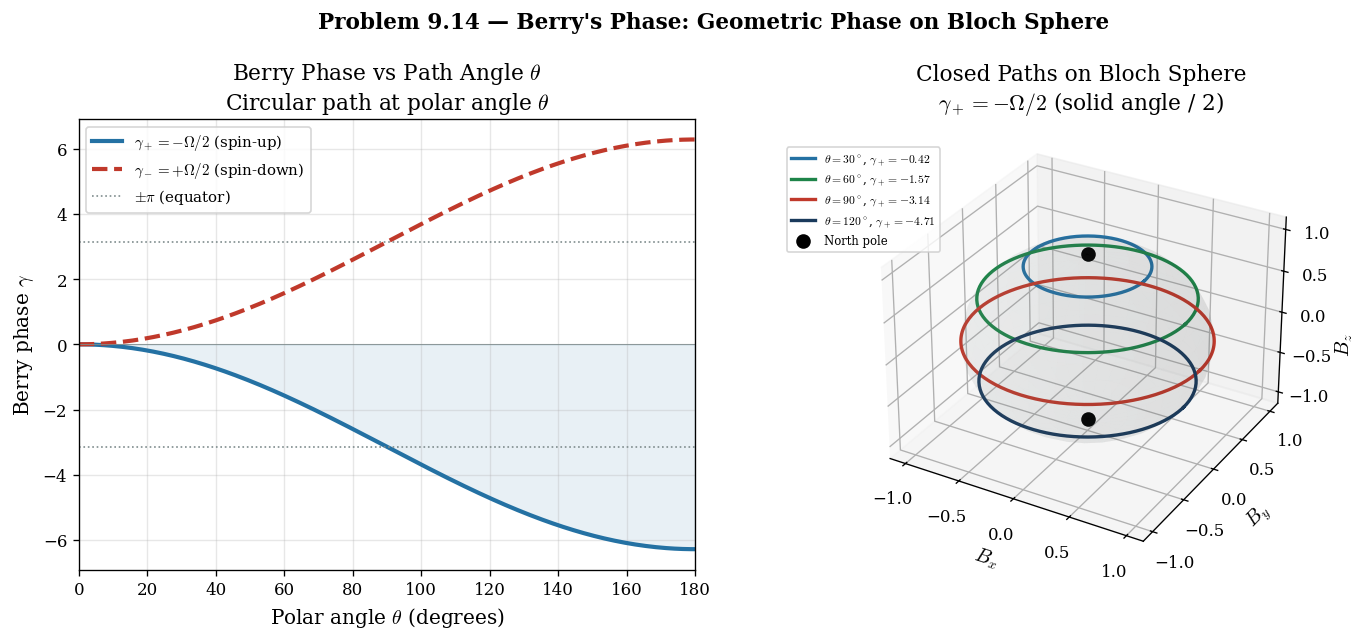

Berry phase gamma_+ = -Omega/2:
  theta=29 deg: Omega=0.8418, gamma_+ = -0.4209
  theta=59 deg: Omega=3.1416, gamma_+ = -1.5708
  theta=90 deg: Omega=6.2832, gamma_+ = -3.1416
  theta=180 deg: Omega=12.5664, gamma_+ = -6.2832


In [7]:
# Figure 9.14: Berry phase — solid angle on Bloch sphere
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Berry phase vs polar angle theta for a circular path
theta_arr = np.linspace(0, np.pi, 300)
solid_angle = 2*np.pi*(1 - np.cos(theta_arr))   # Omega for full circle
berry_plus  = -solid_angle / 2   # gamma_+ = -Omega/2
berry_minus =  solid_angle / 2   # gamma_- = +Omega/2

ax = axes[0]
ax.plot(np.degrees(theta_arr), berry_plus,  color=BLUE, lw=2.5, label=r'$\gamma_+ = -\Omega/2$ (spin-up)')
ax.plot(np.degrees(theta_arr), berry_minus, color=RED,  lw=2.5, ls='--', label=r'$\gamma_- = +\Omega/2$ (spin-down)')
ax.axhline(-np.pi, color=GRAY, ls=':', lw=1, label=r'$\pm\pi$ (equator)')
ax.axhline( np.pi, color=GRAY, ls=':', lw=1)
ax.axhline(0, color=GRAY, ls='-', lw=0.5)
ax.fill_between(np.degrees(theta_arr), berry_plus, 0, alpha=0.1, color=BLUE)
ax.set_xlabel(r'Polar angle $\theta$ (degrees)')
ax.set_ylabel(r'Berry phase $\gamma$')
ax.set_title(r'Berry Phase vs Path Angle $\theta$' '\n'
             r'Circular path at polar angle $\theta$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 180)

# Right: path on Bloch sphere for several theta values
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
axes[1].set_visible(False)

ax2.set_xticks([-1, -0.5, 0, 0.5, 1])
ax2.set_yticks([-1, -0.5, 0, 0.5, 1])
ax2.set_zticks([-1, -0.5, 0, 0.5, 1])

phi_arr = np.linspace(0, 2*np.pi, 200)
# Draw Bloch sphere
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
ax2.plot_surface(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                 alpha=0.06, color=GRAY)

theta_paths = [np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3]
col_paths   = [BLUE, GREEN, RED, NAVY]
for th, c in zip(theta_paths, col_paths):
    Bx = np.sin(th)*np.cos(phi_arr)
    By = np.sin(th)*np.sin(phi_arr)
    Bz = np.cos(th)*np.ones_like(phi_arr)
    SA = 2*np.pi*(1-np.cos(th))
    ax2.plot(Bx, By, Bz, color=c, lw=2,
             label=fr'$\theta={round(np.degrees(th))}^\circ$, $\gamma_+={-SA/2:.2f}$')

ax2.scatter([0],[0],[1],  color='k', s=60, zorder=5, label='North pole')
ax2.scatter([0],[0],[-1], color='k', s=60, zorder=5)
ax2.set_xlabel('$B_x$'); ax2.set_ylabel('$B_y$')
ax2.set_zlabel('')
ax2.text2D(1.06, 0.50, '$B_z$', transform=ax2.transAxes,
           fontsize=12, ha='left', va='center', rotation=90)
ax2.set_title("Closed Paths on Bloch Sphere\n"
              r"$\gamma_+ = -\Omega/2$ (solid angle / 2)")
ax2.legend(fontsize=7, bbox_to_anchor=(0.2, 0.95)) #loc='upper left')

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle("Problem 9.14 — Berry's Phase: Geometric Phase on Bloch Sphere",
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_9_14.png')); plt.show()

print("Berry phase gamma_+ = -Omega/2:")
for th in [np.pi/6, np.pi/3, np.pi/2, np.pi]:
    SA = 2*np.pi*(1-np.cos(th))
    print(f"  theta={int(np.degrees(th))} deg: Omega={SA:.4f}, gamma_+ = {-SA/2:.4f}")


---
## Save All Figures & Download as ZIP


In [8]:
import os, zipfile
save_dir = 'ch09_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch09_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files

    # AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch09_figures/fig_9_1.png
Saved: ch09_figures/fig_9_3.png
Saved: ch09_figures/fig_9_4.png
Saved: ch09_figures/fig_9_9.png
Saved: ch09_figures/fig_9_13.png
Saved: ch09_figures/fig_9_14.png

Zip: ch09_figures.zip,  Files: ['fig_9_1.png', 'fig_9_3.png', 'fig_9_4.png', 'fig_9_9.png', 'fig_9_13.png', 'fig_9_14.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
